   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.7 MB/s eta 0:00:00
2 4
Episode 0: Reward = 13.0, Epsilon = 0.995
Episode 10: Reward = 12.0, Epsilon = 0.946
Episode 20: Reward = 21.0, Epsilon = 0.900
Episode 30: Reward = 22.0, Epsilon = 0.856
Episode 40: Reward = 18.0, Epsilon = 0.814
Episode 50: Reward = 100.0, Epsilon = 0.774
Episode 60: Reward = 102.0, Epsilon = 0.737
Episode 70: Reward = 19.0, Epsilon = 0.701
Episode 80: Reward = 25.0, Epsilon = 0.666
Episode 90: Reward = 28.0, Epsilon = 0.634
[2. 3. 4.]


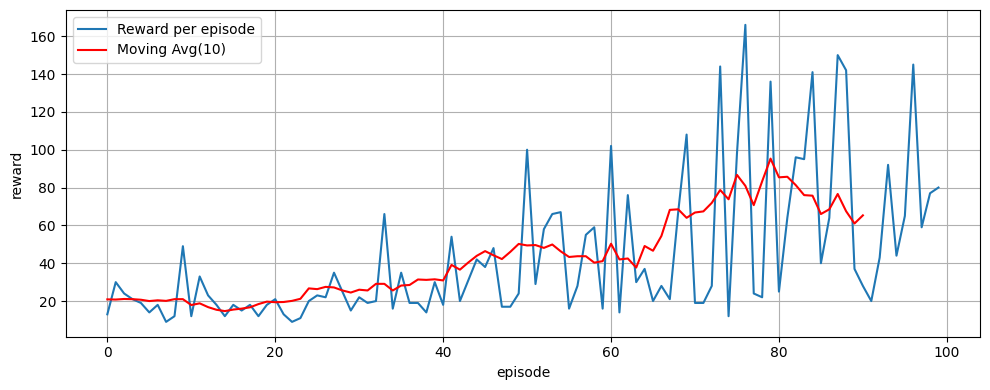

모델 저장 완료


In [2]:
# DQN : Q-learning을 딥러닝 신경망으로 확장한 강화학습 알고리즘
# Q-table 대신 신경망을 사용
# 구조
"""
환경 Environment
 ->
현재 상태 state
 ->
행동별 Q값 예측
 ->
행동 action 선택
 ->
환경에 action 실행
 ->
reward, next_state, done (경험)
 ->
ReplayBuffer에 저장
 ->
랜덤하게 샘플링
 ->
Target Network로 target을 갱신
 ->
Q-Network 학습 (현재 상태를 입력 받아 각 행동의 Q값을 갱신)

*** DQN 동작 비유 ***
학생(Q-Network)이 환경에서 문제를 경험함 : Q-Network가 action을 선택해 행동하면
                                           state, action, reward, next_state, done 발생
    ->
문제은행(Replay Buffer)에 저장 : (state, action, reward, next_state, done)
    ->
문제은행에서 랜덤으로 문제를 꺼냄 : Replay Buffer에서 batch sample
    ->
정답지(Target Network)를 보고 목표값 계산 : target = reward + gammar * max(TargetNetwork(next_state))
    ->
학생 신경망을 갱신 : Q-Network 학습, loss = 현재 Q값 - target Q값


~~~ 이전 CartPole 유지하기 예제를 DQN으로 작업 ~~~
'기존 Q-table 방식'             'DQN 방식'
상태를 이산화해야 함            연속된 상태를 그대로 사용
Q-table로 Q값 예측              신경망 모델이 Q값 예측
argmax(Q[state])                argmax(model.predict(state))
Q[state][action] = r+감마...    model.fit()으로 현재상태 갱신
"""

!pip install gymnasium[classic-control]

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt
import random
import numpy as np

env = gym.make("CartPole-v1")
num_actions = int(env.action_space.n)
state_dim = int(env.observation_space.shape[0])
print(num_actions, state_dim)

# DQN 모델
def create_model():
    model = Sequential([
        Input(shape=(state_dim, )),
        Dense(units=64, activation='relu'),
        Dense(units=64, activation='relu'),
        Dense(units=num_actions, activation='linear')   # 각 행동의 정량적 Q값(제한없는 실수) 출력
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
    return model

model = create_model()   # Q-Netwok(Main Netwok) - 매 상태에서 Q(s, a)를 예측하고 model.fit()을 통해 가중치 계속 갱신

# Target Network (학습중에는 고정된 가중치를 유지하며, 일정 주기마다 model의 가중치를 복사함)
# 사용 목적 : Q-learning의 'moving target' 문제를 방지해 학습 안정성 향상
target_model = create_model()
target_model.set_weights(model.get_weights()) # model과 가중치가 동일하게 초기화
# for i, w in enumerate(model.get_weights()):
#     print(i, '번째 : ', w)

# 하이퍼 파라미터
gammar = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

batch_size = 64   # Replay buffer에서 꺼내 학습에 사용하는 샘플 수
# Replay buffer : 경험(s, a, r, s', done)을 저장해 두는 기억장소
memory = deque(maxlen=5000)

episodes = 100    # 300 ~ 1000 정도 충분히 줘야함

# target network 갱신 주기
update_target_every = 5

reward_list = []

# 학습
# 학습
for ep in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        state_input = np.reshape(state, [1, state_dim])

        # epsilon-greedy 행동 선택
        if np.random.rand() < epsilon:
            action = np.random.choice(num_actions)
        else:
            q_values = model.predict(state_input, verbose=0)
            action = np.argmax(q_values[0])

        # 환경 실행
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        if terminated:
            modified_reward = -10
        else:
            modified_reward = reward

        # Replay Buffer에 경험 저장
        memory.append((state, action, modified_reward, next_state, done))

        state = next_state
        total_reward += reward

        # Replay Buffer에서 batch 추출 후 학습
        if len(memory) >= batch_size:
            minibatch = random.sample(memory, batch_size)

            states = np.array([sample[0] for sample in minibatch])
            actions = np.array([sample[1] for sample in minibatch])
            rewards = np.array([sample[2] for sample in minibatch])
            next_states = np.array([sample[3] for sample in minibatch])
            dones = np.array([sample[4] for sample in minibatch])

            # Main Q-Network로 현재 Q값 예측
            targets = model.predict(states, verbose=0)

            # Target Network로 다음 상태 Q값 예측
            next_q_values = target_model.predict(next_states, verbose=0)

            # 선택한 행동의 Q값만 Bellman target으로 수정
            for i in range(batch_size):
                if dones[i]:
                    targets[i][actions[i]] = rewards[i]
                else:
                    targets[i][actions[i]] = rewards[i] + gammar * np.max(next_q_values[i])

            # Main Q-Network 학습
            model.train_on_batch(states, targets)

    reward_list.append(total_reward)

    # epsilon 감소
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay
        epsilon = max(epsilon, epsilon_min)

    # Target Network 갱신
    if ep % update_target_every == 0:
        target_model.set_weights(model.get_weights())

    if ep % 10 == 0:
        print(f'Episode {ep}: Reward = {total_reward:.1f}, Epsilon = {epsilon:.3f}')
# np.convolve() 이동 평균 구하기
data = np.array([1,2,3,4,5])
window_size = 3
avg = np.convolve(data, np.ones(window_size) / window_size, mode='valid')
print(avg)

# 보상 시각화
plt.figure(figsize=(10, 4))

# data 배열에 대해 window_size 크기의 이동 평균 계산용 함수
def moving_average(data, window_size = 10):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

plt.plot(reward_list, label='Reward per episode')
plt.plot(moving_average(reward_list), label='Moving Avg(10)', color='red')
plt.xlabel('episode')
plt.ylabel('reward')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 모델 저장
model.save('cartpole_model.keras')
print('모델 저장 완료')

In [4]:
# 카트 애니메이션 생성
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tensorflow import keras
env = gym.make('CartPole-v1')
model = keras.models.load_model('cartpole_model.keras')
print(model)

state_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

# 궤적 수집 (1회만 실행)
flat_states = []
episode_labels = []

state, _ = env.reset()
done = False # 종료 조건
ep_num = 0

while not done:
  flat_states.append(state.copy())
  episode_labels.append(ep_num) # 몇번째 프레임인지 표시하기 위해

  state_input = np.reshape(state, [1, state_dim])
  q_values = model.predict(state_input, verbose=0) # q값을 예측하고
  action = np.argmax(q_values[0]) # 행동을 취함

  # 행동을 실제 환경에 적용하고
  next_state, reward, terminated, truncated, _ = env.step(action)
  state = next_state
  done = terminated or truncated

env.close()

<Sequential name=sequential, built=True>


In [5]:
# 시각화 하기
frame_count = len(flat_states)
# print('frame_count :', frame_count) # 3582

fig, ax = plt.subplots()
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title('Cart Pole Simulation')
ax.set_xlabel('Cart Position')
ax.set_ylabel('Height')

# Cart 표시
cart_width = 0.4
cart_height = 0.2
cart_y = 0.0
cart_rect = Rectangle((0,0), cart_width, cart_height, color='black')
ax.add_patch(cart_rect)

# Pole 표시
pole_len = 1.0
line_list = ax.plot([],[], 'r-', lw=4)
pole_line = line_list[0]


episode_text = ax.text(0.05, 1.4, "", transform=ax.transData, fontsize=12, color='blue')

def updateFunc(frame):
    x = flat_states[frame][0]   # cart 위치(x축 좌표)
    theta = flat_states[frame][2]   # pole 각도
    ep_num = episode_labels[frame]  # 현재 프레임의 에피소드 번호
    cart_rect.set_xy((x-cart_width/2, cart_y))      # 카트의 가운데를 기준으로 잡기 위해서

    # 막대 끝 좌표
    x_start = x
    y_start = cart_y + cart_height
    x_end = x_start + pole_len * np.sin(theta)
    y_end = y_start + pole_len * np.cos(theta)
    pole_line.set_data([x_start, x_end], [y_start, y_end])

    episode_text.set_text(f'Episode : {ep_num}')
    return cart_rect, pole_line, episode_text


ani = FuncAnimation(fig, updateFunc, frames=frame_count, interval=50, repeat=False)
plt.close(fig)
display(HTML(ani.to_jshtml()))
# ani.to_jshtml() : 애니메이션을 HTML + Javascript로 변환

Output hidden; open in https://colab.research.google.com to view.